In [1]:
import json
import os
import kagglehub
import importlib
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from IPython.display import JSON
from torch.utils.data import Dataset
from tqdm import tqdm
from functools import partial

In [2]:
from src.jsonl_dataset import JsonLDataset

path = kagglehub.dataset_download("Cornell-University/arxiv/versions/272")
ds_path = os.path.join(path, 'arxiv-metadata-oai-snapshot.json')
ds = JsonLDataset(ds_path)

Indexing dataset at C:\Users\kerem\.cache\kagglehub\datasets\Cornell-University\arxiv\versions\272\arxiv-metadata-oai-snapshot.json... (this may take a minute)
Indexed 2951540 entries.


In [30]:
from src.workers.jsonl_parallel_processor import JsonLParallelProcessor
processor = JsonLParallelProcessor(ds)

In [31]:
# Execute again when the tasks.py file is updated
from src.workers import tasks
importlib.reload(tasks)

<module 'src.workers.tasks' from 'C:\\projects\\personal\\python-notebooks\\interview_irisai\\src\\workers\\tasks.py'>

In [37]:
def random_explore(ds):
    data = random.choice(ds)
    fields = data.keys()
    print(fields)
    print(json.dumps(random.choice(ds), indent=4))
    

In [23]:
print(json.dumps(random.choice(ds), indent=4))

{
    "id": "1211.0361",
    "submitter": "Jae Young Park",
    "authors": "Anna C. Gilbert, Jae Young Park, Michael B. Wakin",
    "title": "Sketched SVD: Recovering Spectral Features from Compressive Measurements",
    "comments": null,
    "journal-ref": null,
    "doi": null,
    "report-no": null,
    "categories": "cs.IT cs.DS math.IT",
    "license": "http://arxiv.org/licenses/nonexclusive-distrib/1.0/",
    "abstract": "  We consider a streaming data model in which n sensors observe individual\nstreams of data, presented in a turnstile model. Our goal is to analyze the\nsingular value decomposition (SVD) of the matrix of data defined implicitly by\nthe stream of updates. Each column i of the data matrix is given by the stream\nof updates seen at sensor i. Our approach is to sketch each column of the\nmatrix, forming a \"sketch matrix\" Y, and then to compute the SVD of the sketch\nmatrix. We show that the singular values and right singular vectors of Y are\nclose to those of X,

# Dataset Structure

In [5]:
def get_date_from_id(arxiv_id):
    """
    Extracts Year and Month from both old (adap-org/9306004) 
    and new (0704.0001) arXiv IDs.
    """
    # Find the first sequence of digits
    match = re.search(r'(\d{4})', arxiv_id.split('/')[-1])
    if match:
        date_str = match.group(1) # e.g., '9306'
        year_short = int(date_str[:2])
        month = int(date_str[2:])
        
        # arXiv started in 1991. 
        # If YY > 90, it's 1900s; otherwise 2000s.
        year = 1900 + year_short if year_short > 90 else 2000 + year_short
        
        # Return as a pandas Period for easy plotting
        return pd.Period(year=year, month=month, freq='M')
    return None

In [6]:
def plot_publication_growth(dates_list, title):
    # 1. Convert list to Series and count occurrences
    date_series = pd.Series(dates_list).dropna()
    
    # Group by Year for a cleaner bar chart
    yearly_counts = date_series.apply(lambda x: x.year).value_counts().sort_index()
    
    # 2. Setup Plot
    plt.figure(figsize=(14, 7))
    sns.set_theme(style="whitegrid")
    
    # 3. Create Barplot
    ax = sns.barplot(x=yearly_counts.index, y=yearly_counts.values, 
                     hue=yearly_counts.index, palette="magma", legend=False)
    
    # 4. Styling
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel("Year", fontsize=12)
    plt.ylabel("Number of Papers", fontsize=12)
    plt.xticks(rotation=45)
    
    # Add trend line
    plt.plot(range(len(yearly_counts)), yearly_counts.values, 
             color='red', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

### IDs
<pre>
    The IDs serve as timestamps for when the paper was published. 
    Format is YYMM.PublishOrder
    e.g. 2508.12467 -> The 12467 Published paper in Augist 2025
    
    IDs before 2007 are in the format Subject/YYMMNumber
    e.g. hep-th/0602172 -> High energy physics theory - February 2006
</pre>

In [7]:
all_ids = processor.map(tasks.get_all_ids)

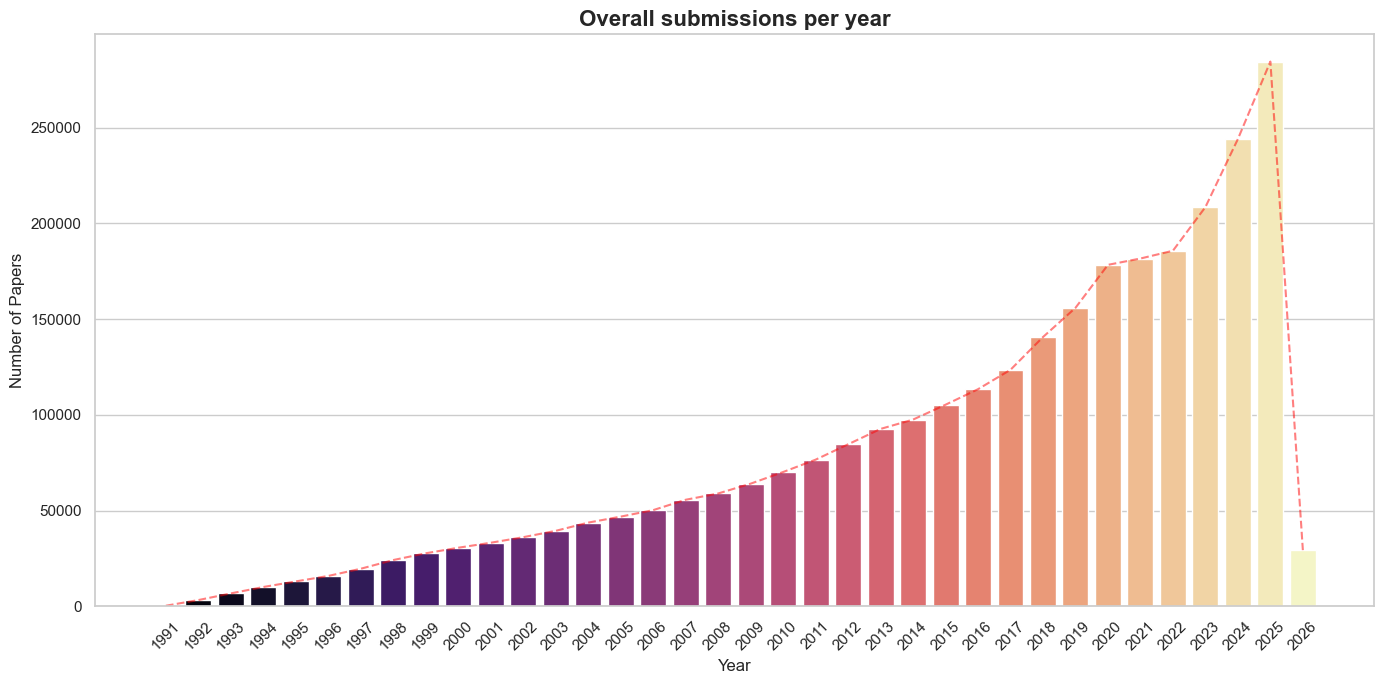

In [8]:
plot_publication_growth([get_date_from_id(_id) for _id in all_ids], "Overall submissions per year")

### All Categories
<pre>
    176 unique categories
    AVG categories per entry - 1.72
    Highly unbalanced

    Two Major categories - astro-ph (105k entries) and cond-mat(15k entries) are being split down after a given time period.
    Probably because of some update in the system through the years, that adds new sub categories to them.
</pre>

In [9]:
all_categories = processor.map(tasks.get_all_categories)

In [11]:
from collections import Counter

def get_category_analytics(categories_list):
    total_entries = len(categories_list)
    tag_counts = Counter()
    total_tags_count = 0
    
    # Process each entry (e.g., "math.CO cs.CG")
    for entry in categories_list:
        if entry:
            tags = entry.split()
            tag_counts.update(tags)
            total_tags_count += len(tags)
    
    # Calculate Metrics
    unique_categories_names = sorted(list(tag_counts.keys()))
    nr_unique_categories = len(unique_categories_names)
    avg_categories_per_entry = total_tags_count / total_entries if total_entries > 0 else 0
    
    return {
        "nr_unique": nr_unique_categories,
        "names": unique_categories_names,
        "avg_per_entry": avg_categories_per_entry,
        "raw_counts": tag_counts, # Useful for top-N analysis later
        "total_tags_count": total_tags_count
    }

analytics = get_category_analytics(all_categories)

print(f"Number of Unique Categories: {analytics['nr_unique']}")
print(f"AVG Categories per Entry:    {analytics['avg_per_entry']:.2f}")
print(f"Total count:    {analytics['total_tags_count']}")

Number of Unique Categories: 176
AVG Categories per Entry:    1.72
Total count:    5088376


In [12]:
def plot_category_distribution(category_counts, top_n=30):
    # 1. Sort and slice the top N categories
    sorted_counts = category_counts.most_common(top_n)
    names, counts = zip(*sorted_counts)
    
    # 2. Setup the plot style
    fig_height = max(6, len(category_counts) * 0.25)
    plt.figure(figsize=(12, fig_height))
    sns.set_theme(style="whitegrid")
    
    # 3. Create horizontal bar chart
    # We use a color palette to make it visually distinct
    ax = sns.barplot(
        x=list(counts), 
        y=list(names), 
        hue=list(names),    # Assign y variable to hue
        palette="viridis", 
        legend=False        # Disable the legend as it's redundant here
    )
    
    # 4. Add labels and titles
    plt.title(f"Showing {top_n} arXiv Categories by Paper Count", fontsize=16, pad=20)
    plt.xlabel("Number of Papers", fontsize=12)
    plt.ylabel("Category Tag", fontsize=12)
    
    # 5. Add value labels to the end of each bar for precision
    for i, count in enumerate(counts):
        ax.text(count + (max(counts) * 0.01), i, f'{count:,}', 
                va='center', fontsize=10, color='black')
    
    plt.tight_layout()
    plt.show()

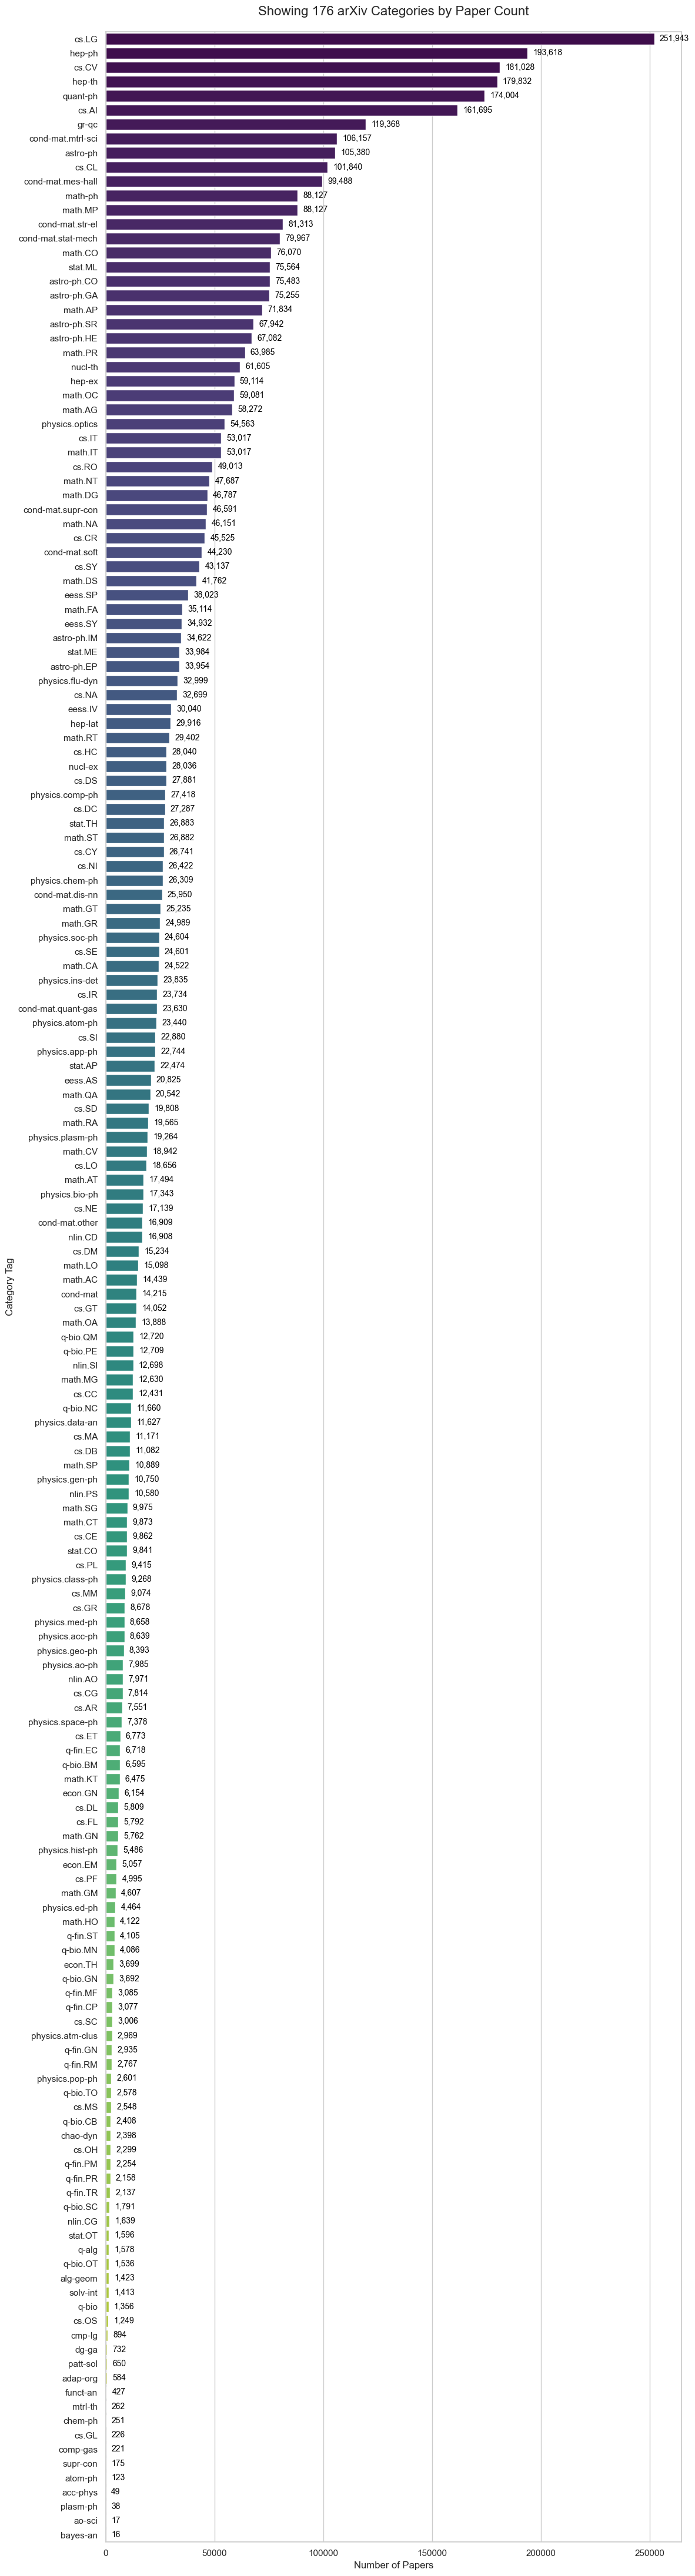

In [13]:
plot_category_distribution(analytics['raw_counts'], top_n=analytics['nr_unique'])

#### Taxonomy
<pre>
    The code below fetches the taxonomy data from Arxiv.org
    It's used for comparison between the dataset categories, and the officialy listed categories in arxiv.
    Some missmatches are found (e.g. 176 classes in the dataset vs 156 from the site)
</pre>

In [14]:
import requests
from bs4 import BeautifulSoup
import json

def scrape_arxiv_taxonomy():
    url = "https://arxiv.org/category_taxonomy"
    res = requests.get(url)
    soup = BeautifulSoup(res.content, 'html.parser')
    
    taxonomy = {}
    
    # arXiv groups categories inside h4 tags (shorthand) 
    # and span tags (full name)
    categories = soup.find_all('h4')
    for cat in categories:
        # Extract shorthand (e.g., cs.LG)
        text = cat.get_text()
        if '(' in text and ')' in text:
            shorthand = text.split('(')[0].strip()
            full_name = text.split('(')[1].replace(')', '').strip()
            taxonomy[shorthand] = full_name
            
    return taxonomy

In [15]:
arxiv_taxonomy = scrape_arxiv_taxonomy()
del(arxiv_taxonomy['Category Name']) # Noise header, comming from bad scraping

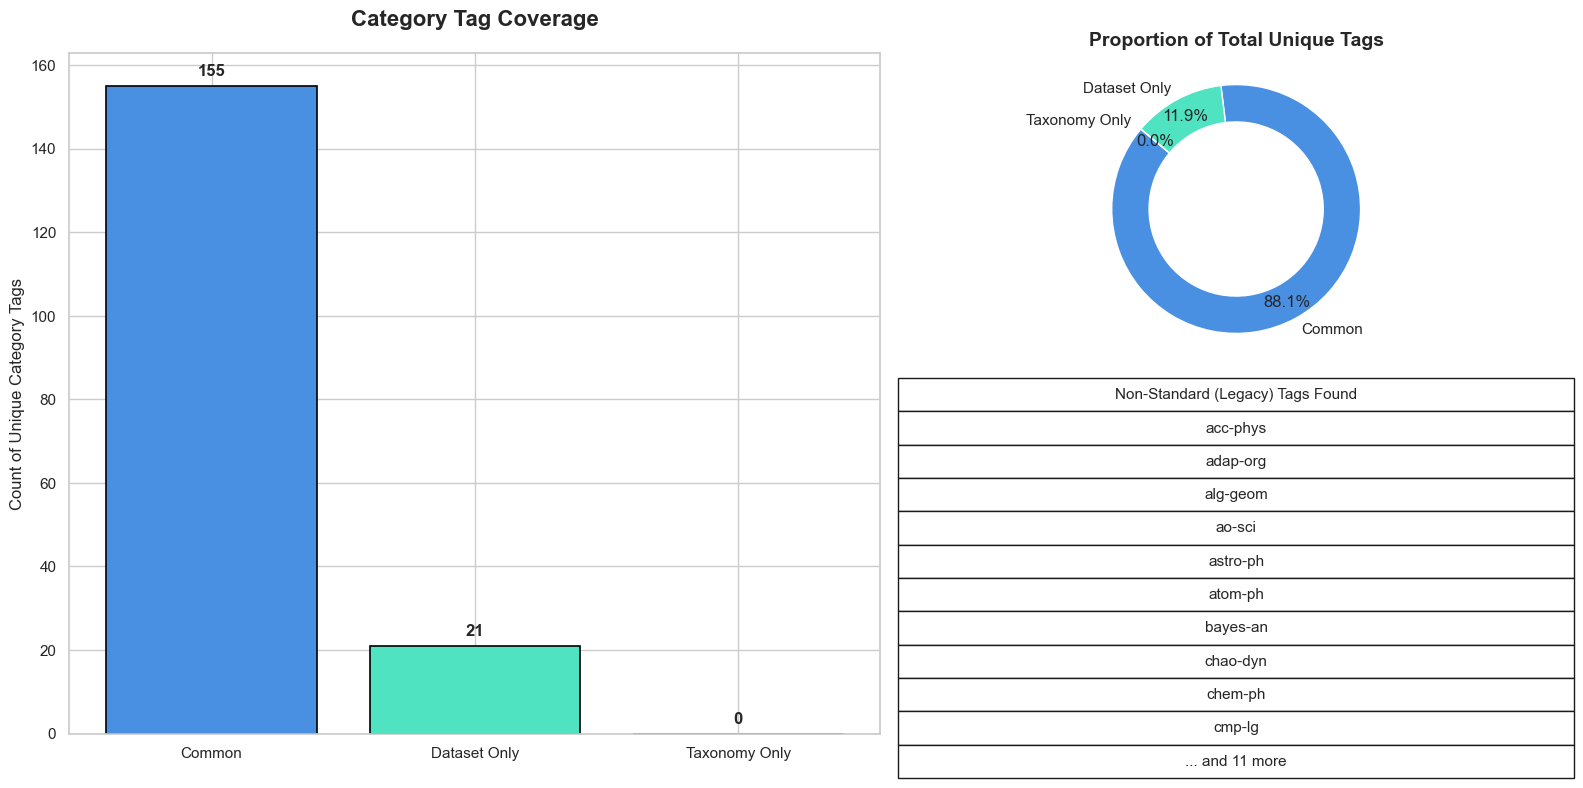

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

def compare_taxonomy_to_dataset(arxiv_taxonomy, dataset_counts):
    """
    Performs a set-theoretic comparison between official taxonomy and dataset tags.
    """
    taxonomy_set = set(arxiv_taxonomy.keys())
    dataset_set = set(dataset_counts.keys())
    
    intersection_set = taxonomy_set.intersection(dataset_set)
    taxonomy_only = taxonomy_set - dataset_set
    dataset_only = dataset_set - taxonomy_set
    
    return {
        "intersection": sorted(list(intersection_set)),
        "taxonomy_only": sorted(list(taxonomy_only)),
        "dataset_only": sorted(list(dataset_only)),
        "counts": {
            "Common": len(intersection_set),
            "Dataset Only": len(dataset_only),
            "Taxonomy Only": len(taxonomy_only)
        }
    }

def visualize_comparison(report):
    """
    Generates a dashboard showing the coverage and specific discrepancies.
    """
    # Initialize the dashboard
    fig = plt.figure(figsize=(16, 8))
    gs = plt.GridSpec(2, 2, width_ratios=[1.2, 1], height_ratios=[1, 1])
    
    # Colors: Professional Blue (Intersection), Teal (Taxonomy Only), Red (Dataset Only)
    colors = ['#4A90E2', '#50E3C2', '#D0021B']
    labels = list(report['counts'].keys())
    values = list(report['counts'].values())

    # 1. Bar Chart: Comparative Counts
    ax1 = fig.add_subplot(gs[:, 0])
    bars = ax1.bar(labels, values, color=colors, edgecolor='black', linewidth=1.2)
    ax1.set_title("Category Tag Coverage", fontsize=16, pad=20, fontweight='bold')
    ax1.set_ylabel("Count of Unique Category Tags", fontsize=12)
    
    # Adding data labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax1.annotate(f'{height}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5), textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    # 2. Donut Chart: Proportional Breakdown
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, 
            colors=colors, pctdistance=0.85, wedgeprops=dict(width=0.3, edgecolor='w'))
    ax2.set_title("Proportion of Total Unique Tags", fontsize=14, fontweight='bold')

    # 3. Table: Highlighting "Dataset Only" Tags
    # These are critical for data cleaning as they represent legacy or non-standard tags
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')
    
    legacy_tags = report['dataset_only']
    display_list = [[tag] for tag in legacy_tags[:10]]
    if len(legacy_tags) > 10:
        display_list.append([f"... and {len(legacy_tags)-10} more"])

    table = ax3.table(cellText=display_list if display_list else [["None Found"]], 
                      colLabels=["Non-Standard (Legacy) Tags Found"], 
                      loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.8)
    
    plt.tight_layout()
    plt.show()

# Execution
comparison_report = compare_taxonomy_to_dataset(arxiv_taxonomy, analytics['raw_counts'])
visualize_comparison(comparison_report)

In [17]:
dataset_unique_counts = Counter({
    tag: analytics['raw_counts'][tag] 
    for tag in comparison_report['dataset_only']
})

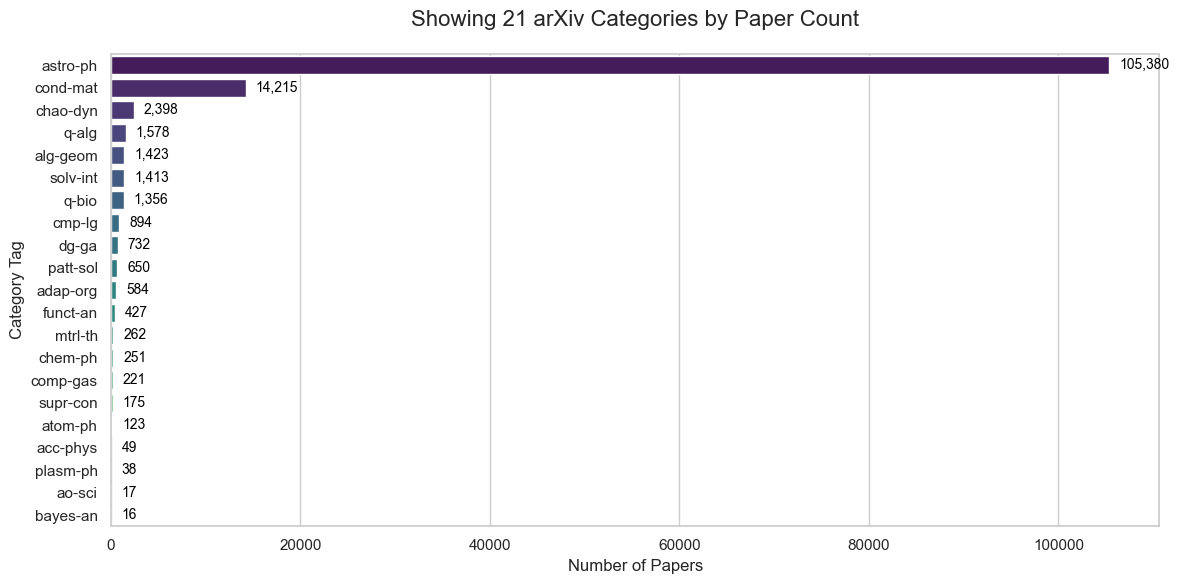

In [18]:
plot_category_distribution(dataset_unique_counts, top_n=len(dataset_unique_counts))

In [19]:
cond_mat_papers = processor.map(partial(tasks.filter_by_category, fields=['id'], category='cond-mat', exact=True))
astro_ph_papers = processor.map(partial(tasks.filter_by_category, fields=['id'], category='astro-ph', exact=True))

In [20]:
cond_mat_dates = [get_date_from_id(p['id']) for p in cond_mat_papers]
astro_ph_dates = [get_date_from_id(p['id']) for p in astro_ph_papers]

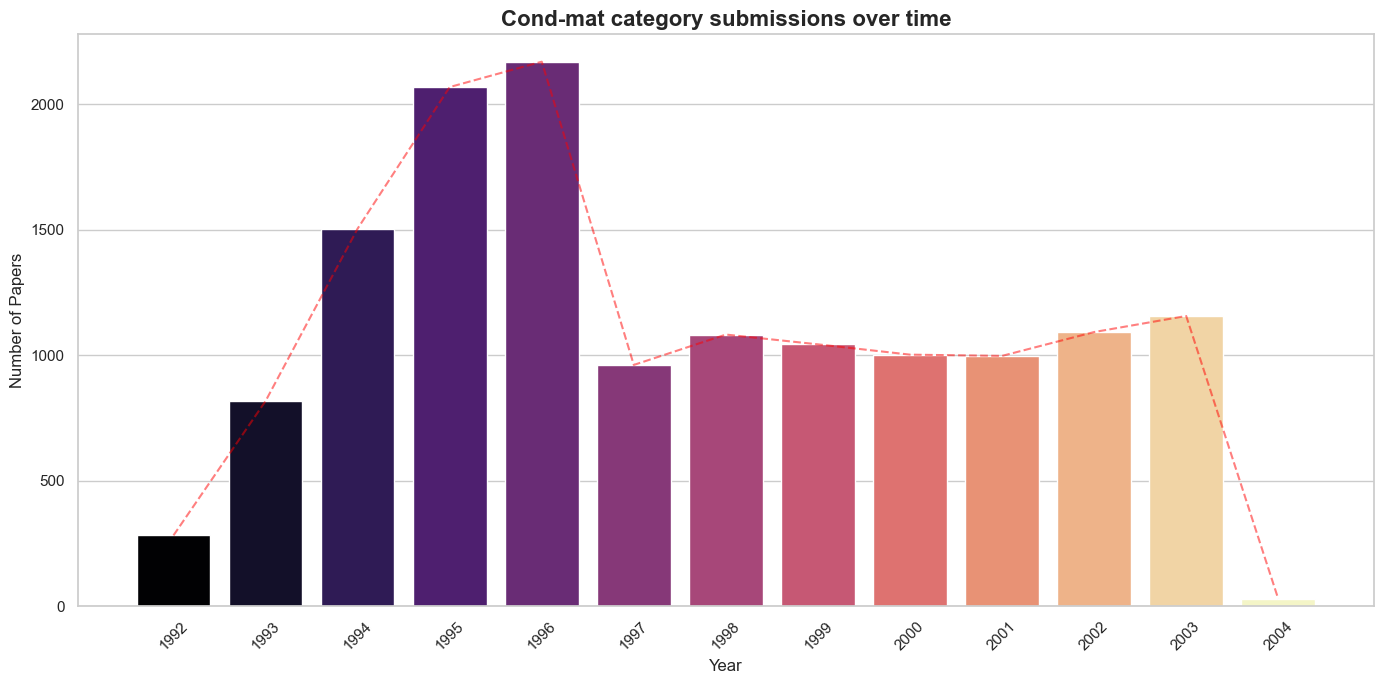

In [21]:
plot_publication_growth(cond_mat_dates, "Cond-mat category submissions over time")

In [23]:
def get_unique_papers(all_papers, existing_papers):
    """
    Returns papers from all_papers that are NOT present in existing_papers.
    """
    # Create a set of IDs for lightning-fast lookup
    existing_ids = {paper['id'] for paper in existing_papers}
    
    # Filter the main list
    unique_papers = [
        paper for paper in all_papers 
        if paper['id'] not in existing_ids
    ]
    
    return unique_papers

In [14]:
all_astro_ph_papers = processor.map(partial(tasks.filter_by_category, fields=['id'], category='astro-ph', exact=False))

In [22]:
diff = get_unique_papers(all_astro_ph_papers, astro_ph_papers)

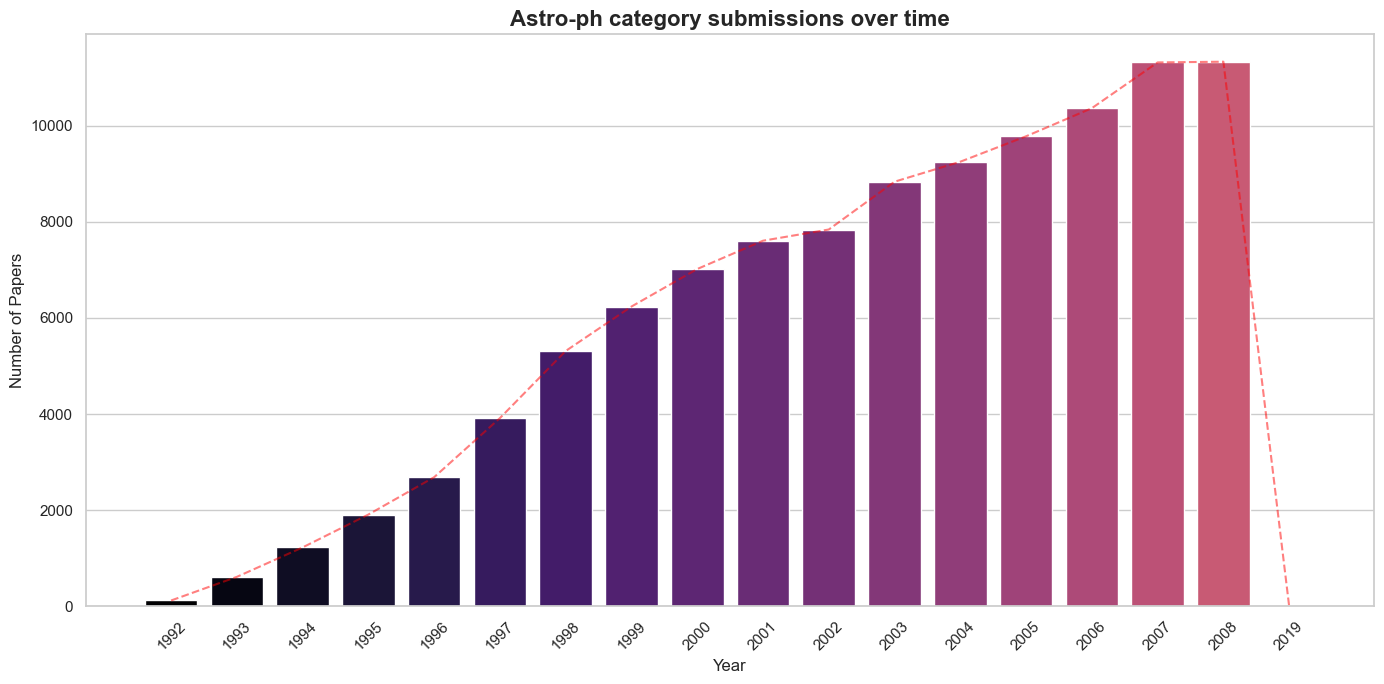

In [52]:
plot_publication_growth(astro_ph_dates, "Astro-ph category submissions over time")

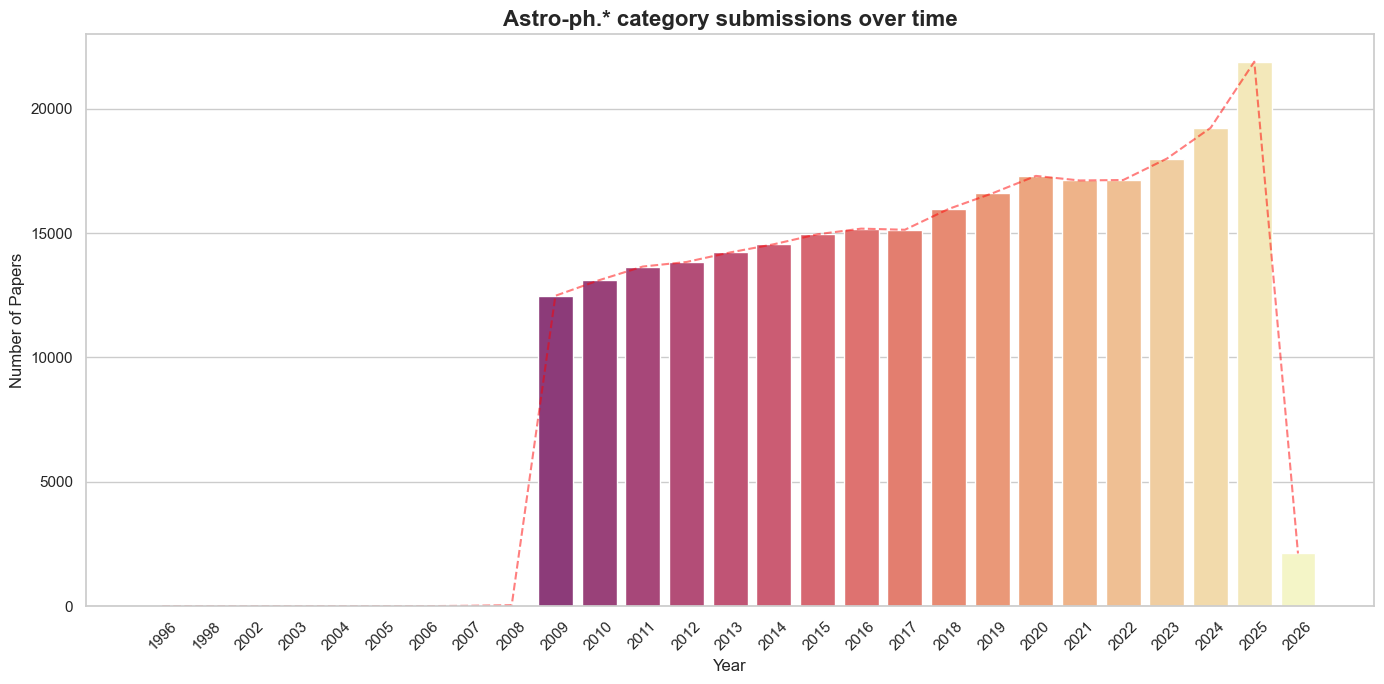

In [28]:
plot_publication_growth([get_date_from_id(p['id']) for p in diff], "Astro-ph.* category submissions over time")

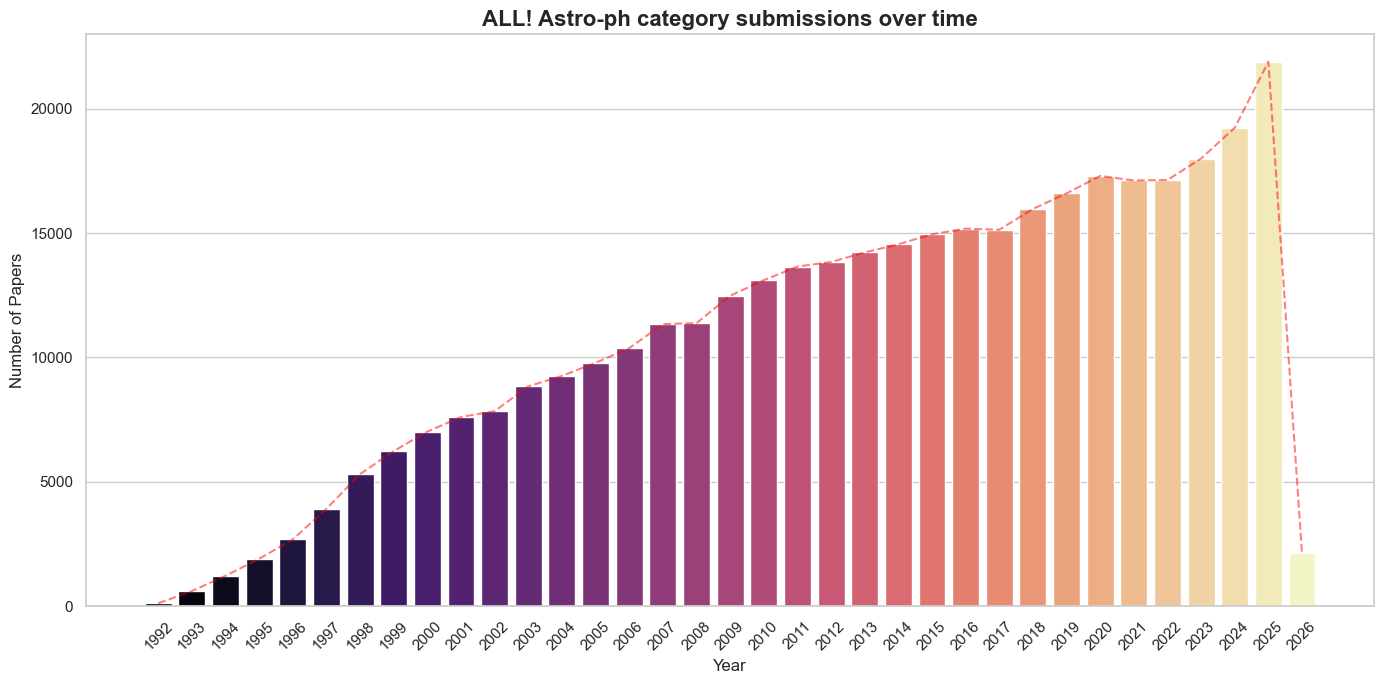

In [54]:
plot_publication_growth([get_date_from_id(p['id']) for p in all_astro_ph_papers], "ALL! Astro-ph category submissions over time")

### Hierarchical Categories

In [24]:
def get_category_hierarchy_map():
    """
    Returns a mapping of every prefix/archive to its official Group.
    Based on arXiv Category Taxonomy (2024 standards).
    """
    # Define the 8 main groups and which prefixes belong to them
    groups = {
        "Physics": [
            "astro-ph", "cond-mat", "gr-qc", "hep-ex", "hep-lat", 
            "hep-ph", "hep-th", "math-ph", "nlin", "nucl-ex", 
            "nucl-th", "physics", "quant-ph"
        ],
        "Mathematics": ["math"],
        "Computer Science": ["cs"],
        "Quantitative Biology": ["q-bio"],
        "Quantitative Finance": ["q-fin"],
        "Statistics": ["stat"],
        "Electrical Engineering and Systems Science": ["eess"],
        "Economics": ["econ"]
    }
    
    # Flatten this for easy lookup: { 'hep-th': 'Physics', 'cs': 'Computer Science' }
    prefix_to_group = {}
    for group_name, prefixes in groups.items():
        for p in prefixes:
            prefix_to_group[p] = group_name
            
    return prefix_to_group

def build_categories_hierarchy(raw_counts):
    mapping = get_category_hierarchy_map()
    hierarchy = {}

    for tag, count in raw_counts.items():
        # 1. Identify the prefix (the part before the dot or the whole legacy name)
        prefix = tag.split('.')[0] if '.' in tag else tag
        
        # 2. Find the official Group
        group = mapping.get(prefix, "Other/Legacy")
        
        # 3. Build the structure: Group -> Archive/Prefix -> Specific Tag
        if group not in hierarchy:
            hierarchy[group] = {"count": 0, "subgroups": {}}
        
        if prefix not in hierarchy[group]["subgroups"]:
            hierarchy[group]["subgroups"][prefix] = {"count": 0, "tags": {}}
            
        hierarchy[group]["count"] += count
        hierarchy[group]["subgroups"][prefix]["count"] += count
        hierarchy[group]["subgroups"][prefix]["tags"][tag] = count
        
    return hierarchy

# Execute
categories_hierarchy = build_categories_hierarchy(analytics['raw_counts'])

In [28]:
json.dump(categories_hierarchy, open("resources/categories_hierarchy.json", 'w'))

In [29]:
JSON(categories_hierarchy)

<IPython.core.display.JSON object>

In [66]:
## Integrity check
_total = 0
for k,v in categories_hierarchy.items():
    _total += v['count']
print(_total)
print(_total == analytics['total_tags_count'])

5088376
True


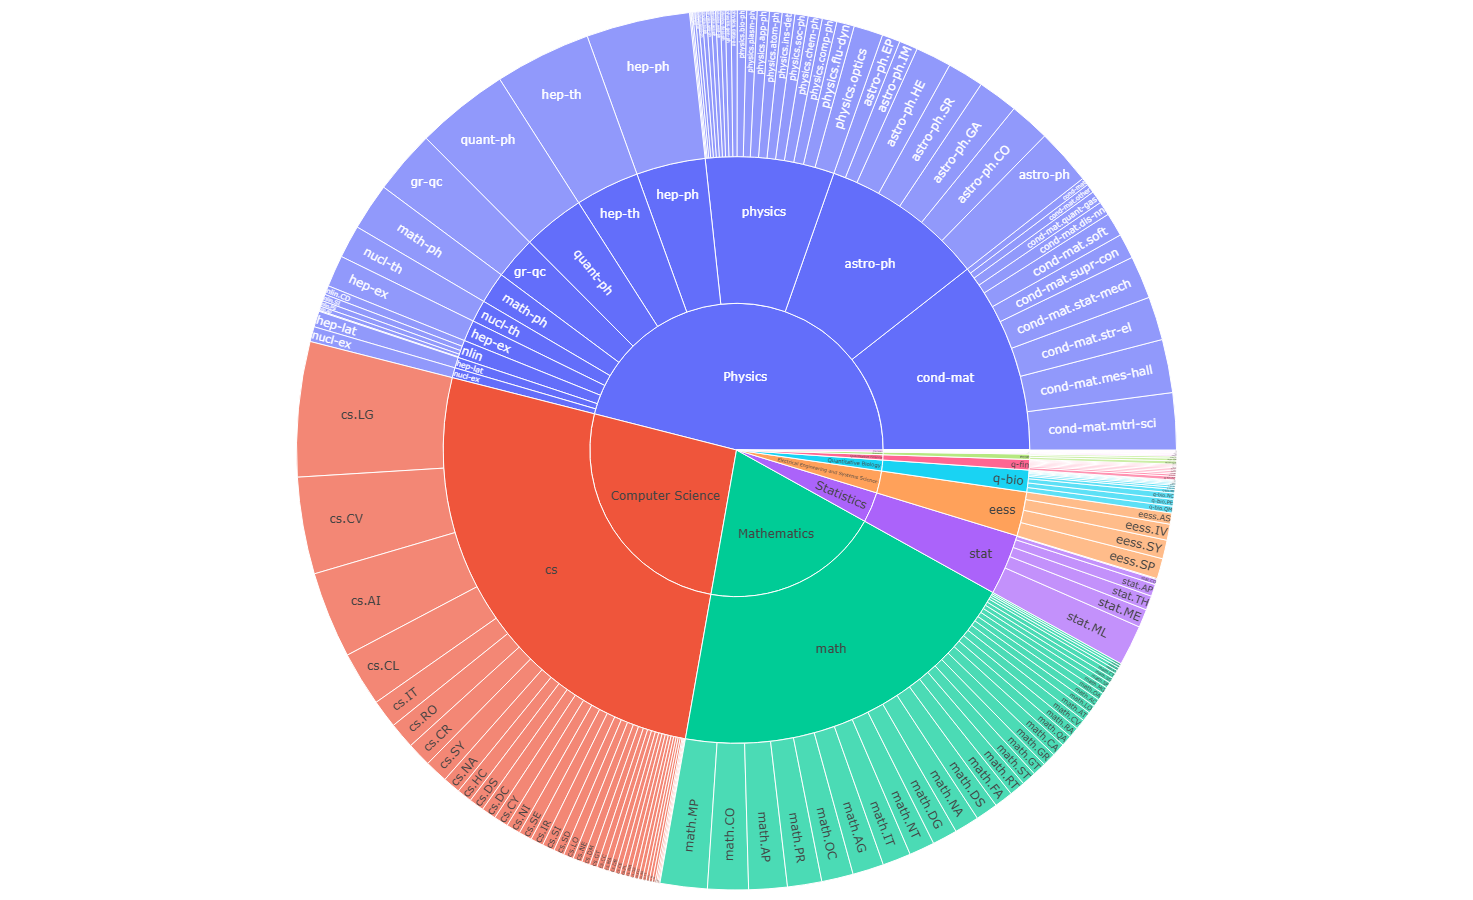

In [12]:
import plotly.graph_objects as go

def plot_hierarchy_sunburst(hierarchy_data):
    ids, labels, parents, values = [], [], [], []

    for group, g_data in hierarchy_data.items():
        # Level 1: The 8 Main Groups
        ids.append(group)
        labels.append(group)
        parents.append("")
        values.append(g_data["count"])
        
        for subgroup, s_data in g_data["subgroups"].items():
            # Level 2: The Archives (e.g., astro-ph, math, cs)
            sub_id = f"{group}_{subgroup}"
            ids.append(sub_id)
            labels.append(subgroup)
            parents.append(group)
            values.append(s_data["count"])
            
            # Level 3: The Specific Tags (Only showing top ones to prevent clutter)
            for tag, count in s_data["tags"].items():
                if count > 500: # Filter small tags for readability
                    ids.append(tag)
                    labels.append(tag)
                    parents.append(sub_id)
                    values.append(count)

    fig = go.Figure(go.Sunburst(
        ids=ids, labels=labels, parents=parents, values=values,
        branchvalues="total",
    ))
    fig.update_layout(margin=dict(t=10, l=10, r=10, b=10), width=900, height=900)
    fig.show()

plot_hierarchy_sunburst(categories_hierarchy)

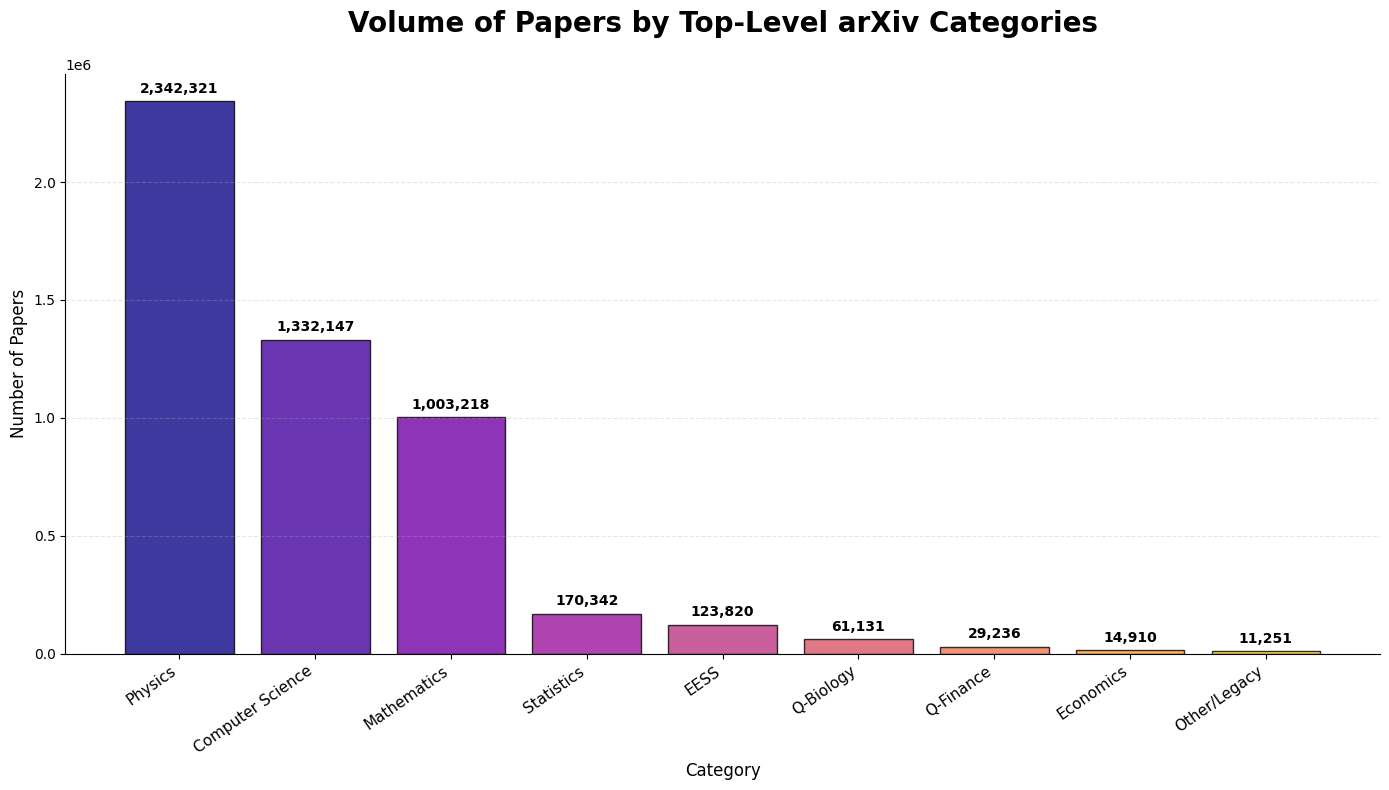

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_top_level_groups_vertical(nested_data):
    """
    Creates a vertical bar chart for top-level arXiv groups.
    """
    # 1. Extract and Sort (Descending for vertical)
    data = [{'Group': g, 'Count': info['count']} for g, info in nested_data.items()]
    df = pd.DataFrame(data).sort_values(by='Count', ascending=False)
    
    # 2. Shorten very long labels for the X-axis
    label_map = {
        "Electrical Engineering and Systems Science": "EESS",
        "Quantitative Biology": "Q-Biology",
        "Quantitative Finance": "Q-Finance",
        "Other/Legacy": "Other/Legacy"
    }
    df['DisplayLabel'] = df['Group'].apply(lambda x: label_map.get(x, x))

    # 3. Setup Plot
    plt.figure(figsize=(14, 8))
    colors = plt.cm.plasma([i/len(df) for i in range(len(df))]) # Using Plasma palette
    
    # 4. Create Bars
    bars = plt.bar(df['DisplayLabel'], df['Count'], color=colors, edgecolor='black', alpha=0.8)
    
    # 5. Add Count Labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + (df['Count'].max() * 0.01),
                 f'{int(height):,}', ha='center', va='bottom', fontweight='bold')

    # 6. Styling
    plt.title("Volume of Papers by Top-Level arXiv Categories", fontsize=20, fontweight='bold', pad=30)
    plt.ylabel("Number of Papers", fontsize=12)
    plt.xlabel("Category", fontsize=12)
    
    # Rotate labels to ensure they are readable
    plt.xticks(rotation=35, ha='right', fontsize=11)
    
    # Clean up aesthetics
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Run the vertical plot
plot_top_level_groups_vertical(categories_hierarchy)

In [30]:
from src.utils import remap_to_modern_standard

# Example Usage:
print(remap_to_modern_standard("cmp-lg"))   # Output: cs.CL
print(remap_to_modern_standard("alg-geom")) # Output: math.AG
print(remap_to_modern_standard("cs.AI"))    # Output: cs.AI (No change)

cs.CL
math.AG
cs.AI


In [29]:
remap_to_modern_standard("hep-ph")

'hep-ph'

In [40]:
from src.utils import get_parent_category

get_parent_category("astro-ph", json.load(open("resources/categories_hierarchy.json",'r')))

'Physics'